Seasonal agriculture performance analysis


Major data analytics project
Domain:agriculture
Project Theme:seasonal agriculture performace
Tools:Python,pandas.numpy,matplotlib,seaborn

Project goal

The main goal of this project is to analyze agricultural data and identify factors affecting crop yield, profitability, and water efficiency. It aims to clean the data, find important patterns and trends, calculate key KPIs, and present useful insights through data analysis and visualizations to support better agricultural decision-making.





Problem statement

Agricultural data contains various factors affecting crop yield, profitability, and resource usage. The problem is to clean and analyze this data, identify important patterns and relationships, and generate useful insights for better agricultural decision-making.




project object

* To clean and preprocess the agricultural dataset.
* To analyze factors affecting crop yield and profitability.
* To compare crop performance across seasons and regions.
* To analyze irrigation and water efficiency.
* To calculate important KPIs such as yield, profit margin, and revenue per hectare.
* To identify patterns, trends, and relationships in the data.
* To present findings through clear visualizations and dashboards.
* To provide data-driven insights for better agricultural decision-making.


dataset

The dataset contains  4,000 agricultural records with 28 attributes, covering crop, seasonal, environmental, irrigation, production, cost, revenue, profit, and water-usage information. It can be used to analyze crop performance, profitability, yield, and resource efficiency across different farming conditions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

Initial data understanding


In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


In [5]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Pro

In [7]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

missing value handling


In [27]:
# Missing values
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df)) * 100
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

print(missing_df)

                 Missing Values  Percentage
Yield_Tonnes_Ha              32         0.8


data cleaning

In [28]:
# Make a copy
clean_df = df.copy()

# Numerical columns
numeric_cols = clean_df.select_dtypes(include=np.number).columns

# Fill missing numerical values with median
for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Categorical columns
categorical_cols = clean_df.select_dtypes(include="object").columns

# Fill missing categorical values with mode
for col in categorical_cols:
    if clean_df[col].isnull().sum() > 0:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

# Check missing values again
print("Total missing values:", clean_df.isnull().sum().sum())

Total missing values: 0


removing duplicates

In [29]:
print("Duplicates before:", clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates()

print("Duplicates after:", clean_df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [30]:
# Check important columns for negative values
check_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Water_Used_m3"
]

for col in check_columns:
    print(col, "negative values:", (clean_df[col] < 0).sum())

Farm_Area_Hectares negative values: 0
Rainfall_mm negative values: 0
Avg_Temperature_C negative values: 0
Humidity_pct negative values: 0
Soil_pH negative values: 0
Soil_Moisture_pct negative values: 0
Nitrogen_kg_ha negative values: 0
Phosphorus_kg_ha negative values: 0
Potassium_kg_ha negative values: 0
Fertilizer_kg_ha negative values: 0
Pesticide_Litre_ha negative values: 0
Yield_Tonnes_Ha negative values: 0
Production_Tonnes negative values: 0
Market_Price_INR_Tonne negative values: 0
Total_Cost_INR negative values: 0
Revenue_INR negative values: 0
Water_Used_m3 negative values: 0


In [32]:
# Profit Margin
clean_df["Profit_Margin_%"] = (
    clean_df["Profit_INR"] / clean_df["Revenue_INR"] * 100
)

# Cost per tonne
clean_df["Cost_Per_Tonne"] = (
    clean_df["Total_Cost_INR"] / clean_df["Production_Tonnes"]
)

# Revenue per hectare
clean_df["Revenue_Per_Hectare"] = (
    clean_df["Revenue_INR"] / clean_df["Farm_Area_Hectares"]
)

# Profit per hectare
clean_df["Profit_Per_Hectare"] = (
    clean_df["Profit_INR"] / clean_df["Farm_Area_Hectares"]
)

# Production per hectare
clean_df["Production_Per_Hectare"] = (
    clean_df["Production_Tonnes"] / clean_df["Farm_Area_Hectares"]
)

# Profit/Loss category
clean_df["Profit_Status"] = np.where(
    clean_df["Profit_INR"] >= 0,
    "Profit",
    "Loss"
)

clean_df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Revenue_per_Hectare,Profit_per_Hectare,Production_per_Hectare,Cost_per_Tonne,Profit_Margin_%,Cost_Per_Tonne,Revenue_Per_Hectare,Profit_Per_Hectare,Production_Per_Hectare,Profit_Status
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,58132.075472,-22362.264151,2.452830,32816.923077,-38.468030,32816.923077,58132.075472,-22362.264151,2.452830,Loss
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,6186.983155,-69211.332312,0.300153,251199.489796,-1118.660429,251199.489796,6186.983155,-69211.332312,0.300153,Loss
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,39190.534979,-25667.489712,0.520576,124588.932806,-65.494104,124588.932806,39190.534979,-25667.489712,0.520576,Loss
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,44608.888889,-21267.555556,1.840000,35802.415459,-47.675600,35802.415459,44608.888889,-21267.555556,1.840000,Loss
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,45987.410926,-34287.885986,2.209026,36339.677419,-74.559288,36339.677419,45987.410926,-34287.885986,2.209026,Loss


In [33]:
total_farms = clean_df["Farm_ID"].nunique()
total_production = clean_df["Production_Tonnes"].sum()
total_revenue = clean_df["Revenue_INR"].sum()
total_cost = clean_df["Total_Cost_INR"].sum()
total_profit = clean_df["Profit_INR"].sum()
average_yield = clean_df["Yield_Tonnes_Ha"].mean()
average_water_efficiency = clean_df["Water_Efficiency_t_per_1000m3"].mean()

print("Total Farms:", total_farms)
print("Total Production:", round(total_production, 2), "Tonnes")
print("Total Revenue: ₹", round(total_revenue, 2))
print("Total Cost: ₹", round(total_cost, 2))
print("Total Profit: ₹", round(total_profit, 2))
print("Average Yield:", round(average_yield, 2), "Tonnes/Ha")
print("Average Water Efficiency:", round(average_water_efficiency, 2))

Total Farms: 4000
Total Production: 172984.84 Tonnes
Total Revenue: ₹ 2551440192
Total Cost: ₹ 2105214332
Total Profit: ₹ 446225860
Average Yield: 5.24 Tonnes/Ha
Average Water Efficiency: 5.39


crop-wise analysis

In [34]:
crop_yield = (
    clean_df.groupby("Crop")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

print(crop_yield)

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


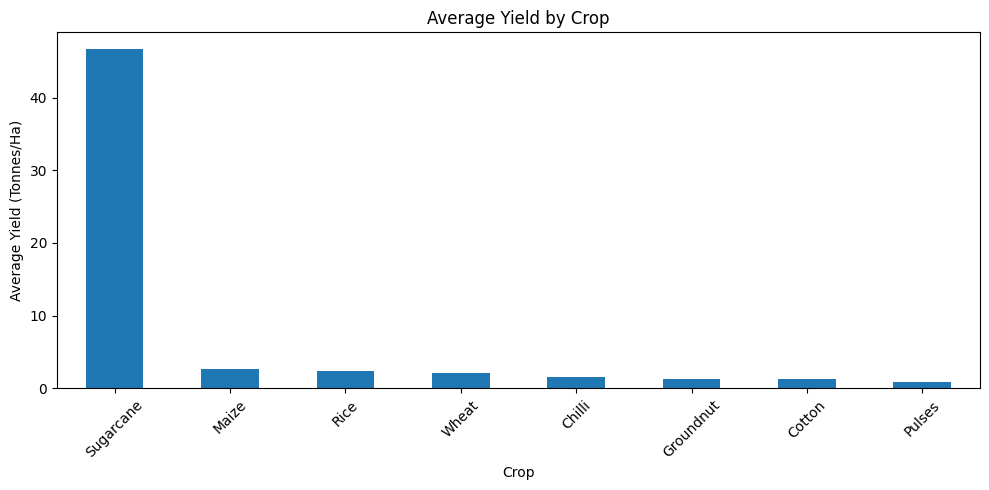

In [35]:
plt.figure(figsize=(10, 5))

crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
crop_profit = (
    clean_df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

print(crop_profit)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


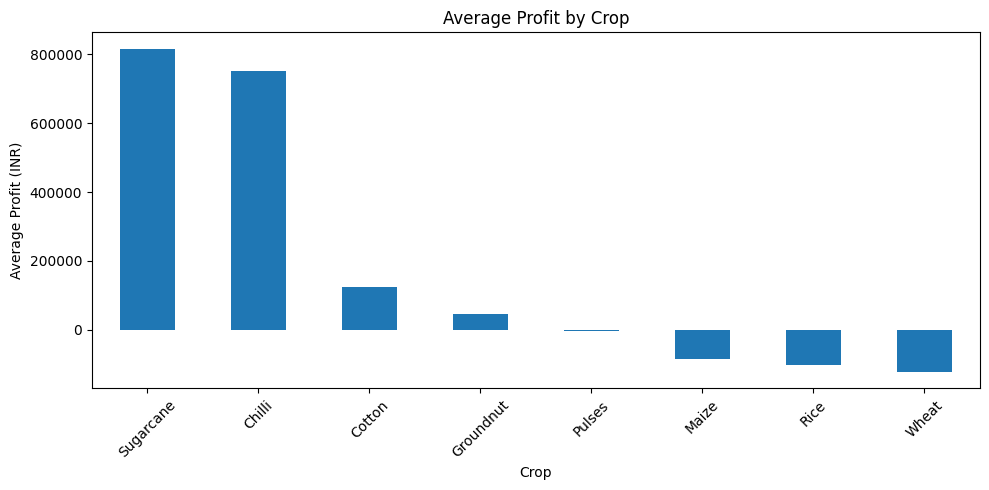

In [37]:
plt.figure(figsize=(10, 5))

crop_profit.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

State-wise performance

In [38]:
state_analysis = clean_df.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "sum",
    "Revenue_INR": "sum",
    "Total_Cost_INR": "sum",
    "Profit_INR": "sum"
}).sort_values("Profit_INR", ascending=False)

state_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
State,,,,,
Maharashtra,5.017480,22519.83,332816727,263477153,69339574
Punjab,6.121116,25280.82,332133240,266296832,65836408
Karnataka,5.685481,23341.30,319525403,261127881,58397522
Gujarat,5.659016,23586.01,319490116,262116817,57373299
Tamil Nadu,4.875175,19807.58,305110307,248004104,57106203
Telangana,5.044477,20255.16,324452819,268296737,56156082
Madhya Pradesh,4.989940,18667.08,296986504,253826648,43159856
Andhra Pradesh,4.628771,19527.06,320925076,282068160,38856916


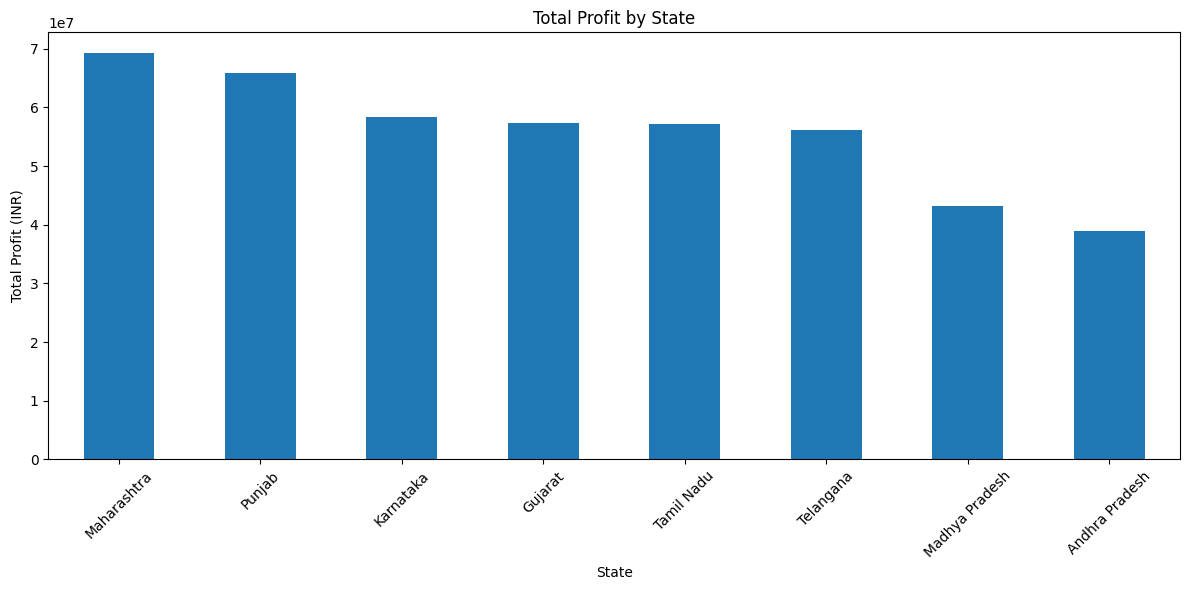

In [39]:
plt.figure(figsize=(12, 6))

state_analysis["Profit_INR"].plot(kind="bar")

plt.title("Total Profit by State")
plt.xlabel("State")
plt.ylabel("Total Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Season-wise analysis

In [40]:
season_analysis = clean_df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "sum",
    "Revenue_INR": "sum",
    "Profit_INR": "sum"
})

season_analysis

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.628612,82387.61,1264369200,318289158
Rabi,5.039435,67498.88,978682881,142670768
Zaid,4.641313,23098.35,308388111,-14734066


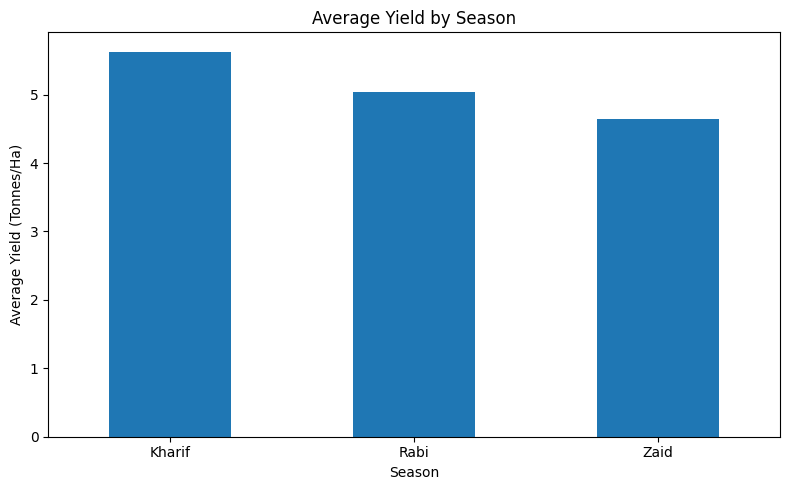

In [41]:
plt.figure(figsize=(8, 5))

season_analysis["Yield_Tonnes_Ha"].plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Irrigation method analysis

In [42]:
irrigation_analysis = clean_df.groupby("Irrigation_Method").agg({
    "Yield_Tonnes_Ha": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Profit_INR": "mean"
}).sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

irrigation_analysis

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.577989,5918.747541,6.267129,219625.997814
Sprinkler,5.160627,6208.258856,4.669805,91121.079019
Flood,4.863977,8026.472519,3.438853,73354.022901
Rainfed,4.602142,3549.554275,7.563784,79050.365034


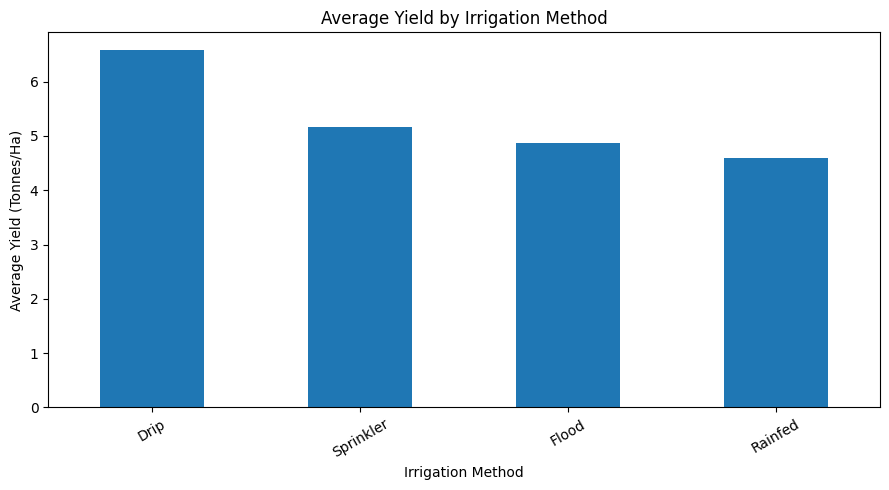

In [43]:
plt.figure(figsize=(9, 5))

irrigation_analysis["Yield_Tonnes_Ha"].plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Fertilizer vs yield

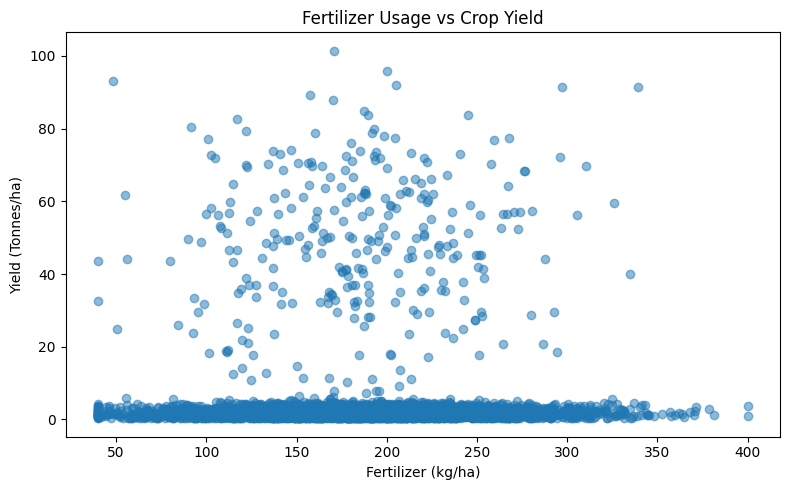

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Fertilizer_kg_ha"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

Rainfall vs yield

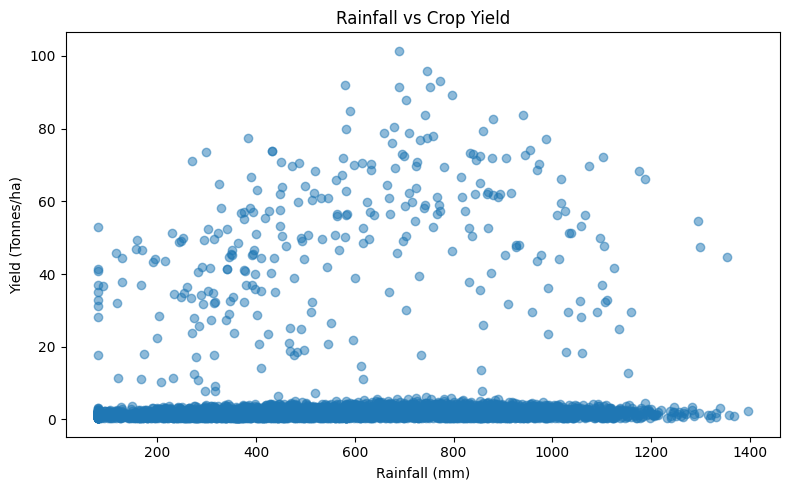

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Rainfall_mm"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

Temperature vs yield

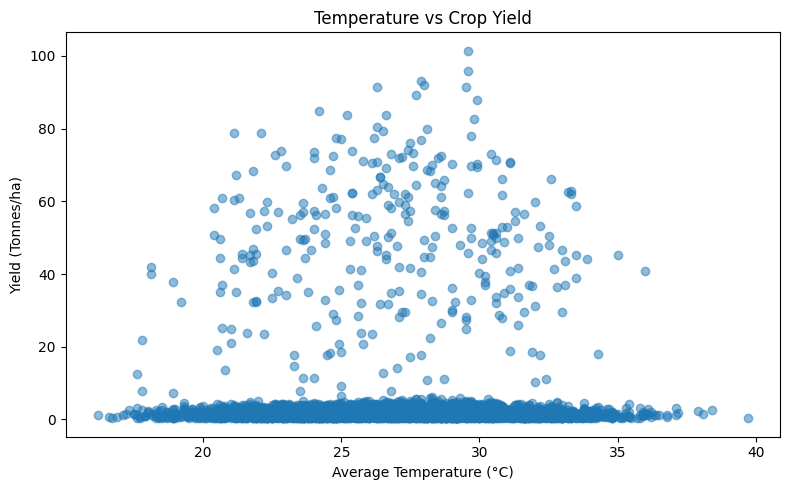

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Avg_Temperature_C"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

Seed quality vs yield

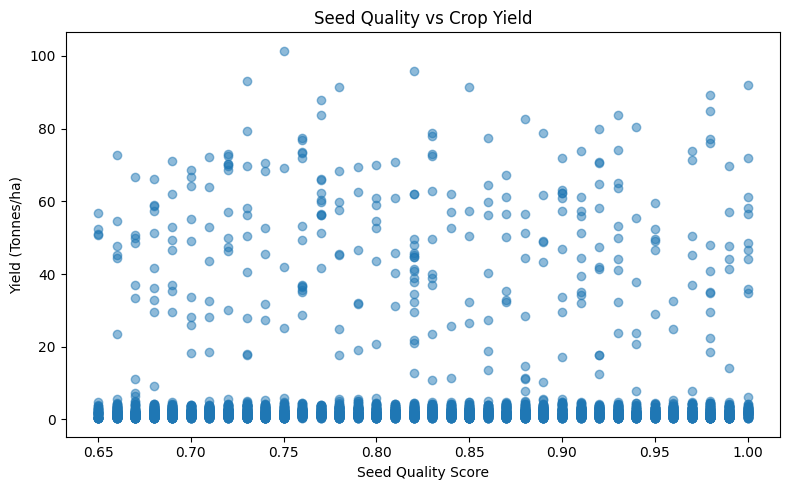

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Seed_Quality_Score"],
    clean_df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Seed Quality vs Crop Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/ha)")
plt.tight_layout()
plt.show()

Disease/Pest risk analysis

In [48]:
risk_analysis = (
    clean_df.groupby("Crop")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

print(risk_analysis)

Crop
Wheat        47.854723
Pulses       46.570161
Rice         46.495797
Groundnut    46.289151
Chilli       46.062136
Cotton       45.974606
Maize        45.539564
Sugarcane    45.403934
Name: Disease_Pest_Risk_pct, dtype: float64


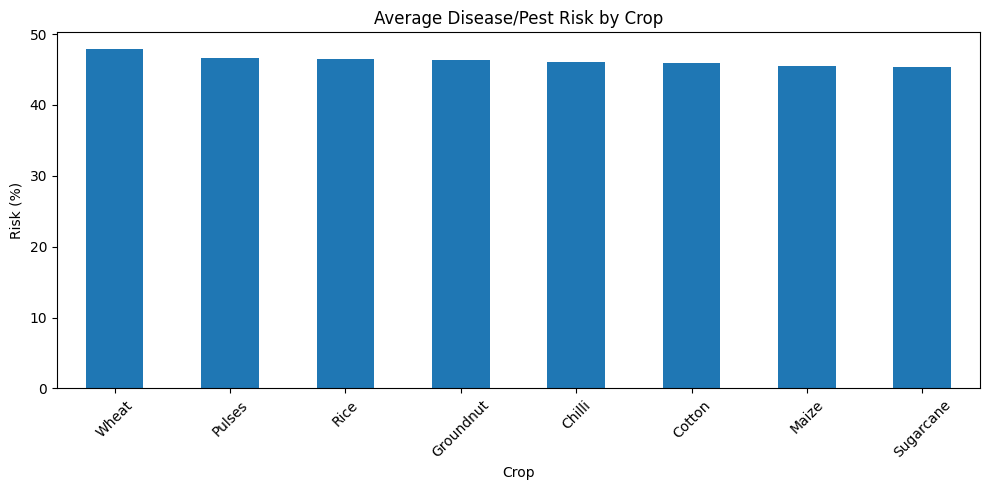

In [49]:
plt.figure(figsize=(10, 5))

risk_analysis.plot(kind="bar")

plt.title("Average Disease/Pest Risk by Crop")
plt.xlabel("Crop")
plt.ylabel("Risk (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Water efficiency analysis

In [50]:
water_analysis = clean_df.groupby("Irrigation_Method").agg({
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Yield_Tonnes_Ha": "mean"
}).sort_values(
    "Water_Efficiency_t_per_1000m3",
    ascending=False
)

water_analysis

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha
Irrigation_Method,,,
Rainfed,3549.554275,7.563784,4.602142
Drip,5918.747541,6.267129,6.577989
Sprinkler,6208.258856,4.669805,5.160627
Flood,8026.472519,3.438853,4.863977


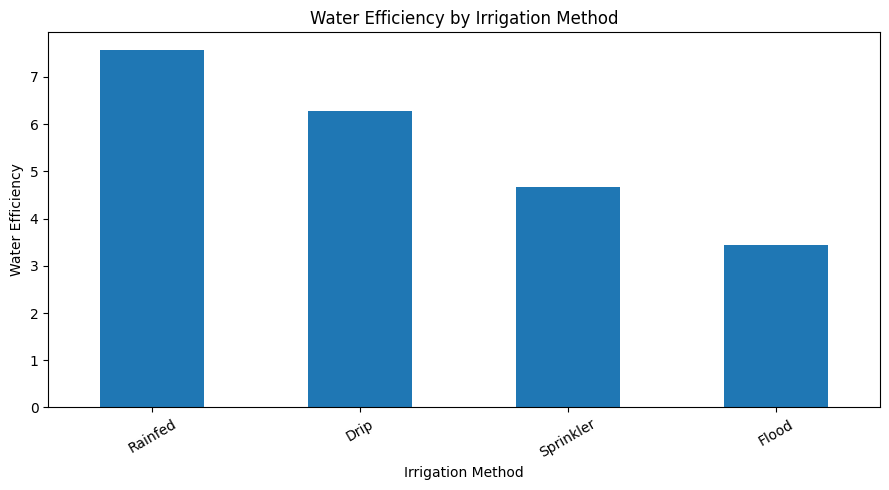

In [51]:
plt.figure(figsize=(9, 5))

water_analysis["Water_Efficiency_t_per_1000m3"].plot(kind="bar")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Cost vs profit analysis

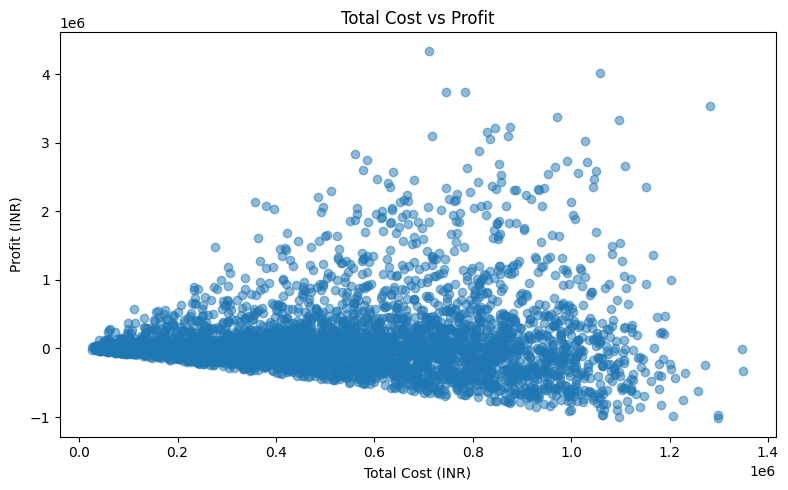

In [52]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Total_Cost_INR"],
    clean_df["Profit_INR"],
    alpha=0.5
)

plt.title("Total Cost vs Profit")
plt.xlabel("Total Cost (INR)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

Find most profitable crops

In [53]:
most_profitable_crops = (
    clean_df.groupby("Crop")
    .agg(
        Average_Profit=("Profit_INR", "mean"),
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Cost=("Total_Cost_INR", "mean")
    )
    .sort_values("Average_Profit", ascending=False)
)

most_profitable_crops

,Average_Profit,Average_Yield,Average_Revenue,Average_Cost
Crop,,,,
Sugarcane,817187.986885,46.642361,1.371980e+06,554792.127869
Chilli,750878.342233,1.542767,1.276777e+06,525898.885922
Cotton,124546.915354,1.229783,6.394231e+05,514876.167323
Groundnut,44858.120283,1.322901,5.429355e+05,498077.377358
Pulses,-4238.052419,0.921512,5.284659e+05,532703.919355
Maize,-83978.326679,2.710036,4.570680e+05,541046.317604
Rice,-102213.504348,2.431304,4.236153e+05,525828.763768
Wheat,-123398.337134,2.108013,4.001049e+05,523503.223127


Find best crop + season combination

In [54]:
crop_season = (
    clean_df.groupby(["Crop", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        )
    )
    .sort_values("Average_Profit", ascending=False)
)

crop_season.head(15)

,,Average_Yield,Average_Profit,Average_Water_Efficiency
Crop,Season,,,
Sugarcane,Kharif,53.459120,1.000791e+06,36.003912
Chilli,Kharif,1.731459,9.543804e+05,3.259514
Sugarcane,Rabi,43.286124,7.316129e+05,27.924581
Chilli,Rabi,1.465031,6.385725e+05,2.885988
Sugarcane,Zaid,38.423922,5.836358e+05,23.390784
Chilli,Zaid,1.195312,4.486591e+05,2.203594
Cotton,Kharif,1.374512,2.169995e+05,2.130521
Groundnut,Kharif,1.484974,1.082654e+05,3.584078
Cotton,Rabi,1.198358,1.073436e+05,1.937657


Find loss-making farms

In [55]:
loss_farms = clean_df[
    clean_df["Profit_INR"] < 0
].copy()

print("Number of loss-making farms:", len(loss_farms))

loss_farms[
    [
        "Farm_ID",
        "State",
        "Crop",
        "Season",
        "Total_Cost_INR",
        "Revenue_INR",
        "Profit_INR"
    ]
].head(20)

Number of loss-making farms: 1966


,Farm_ID,State,Crop,Season,Total_Cost_INR,Revenue_INR,Profit_INR
0,SF10001,Andhra Pradesh,Wheat,Kharif,42662,30810,-11852
1,SF10002,Maharashtra,Maize,Kharif,492351,40401,-451950
2,SF10003,Telangana,Pulses,Rabi,315210,190466,-124744
3,SF10004,Telangana,Rice,Kharif,296444,200740,-95704
4,SF10005,Karnataka,Maize,Zaid,337959,193607,-144352
5,SF10006,Gujarat,Pulses,Zaid,302333,269570,-32763
6,SF10007,Telangana,Wheat,Rabi,513341,472102,-41239
10,SF10011,Maharashtra,Wheat,Rabi,289759,140857,-148902
11,SF10012,Telangana,Maize,Rabi,964512,385097,-579415
12,SF10013,Punjab,Wheat,Rabi,335153,42063,-293090


Find profitable farms

In [56]:
profitable_farms = clean_df[
    clean_df["Profit_INR"] > 0
].copy()

print("Number of profitable farms:", len(profitable_farms))

Number of profitable farms: 2034


Correlation analysis

In [57]:
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct",
    "Profit_INR"
]

correlation = clean_df[correlation_columns].corr()

# Correlation with Yield
yield_corr = (
    correlation["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

print("Factors related to Yield:")
print(yield_corr)

Factors related to Yield:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Profit_INR                       0.488466
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Name: Yield_Tonnes_Ha, dtype: float64


Find factors related to profit

In [58]:
profit_corr = (
    correlation["Profit_INR"]
    .sort_values(ascending=False)
)

print("Factors related to Profit:")
print(profit_corr)

Factors related to Profit:
Profit_INR                       1.000000
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Water_Used_m3                    0.190278
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


### Correlation Heatmap

Let's visualize the correlation matrix to see the relationships between different numerical features.

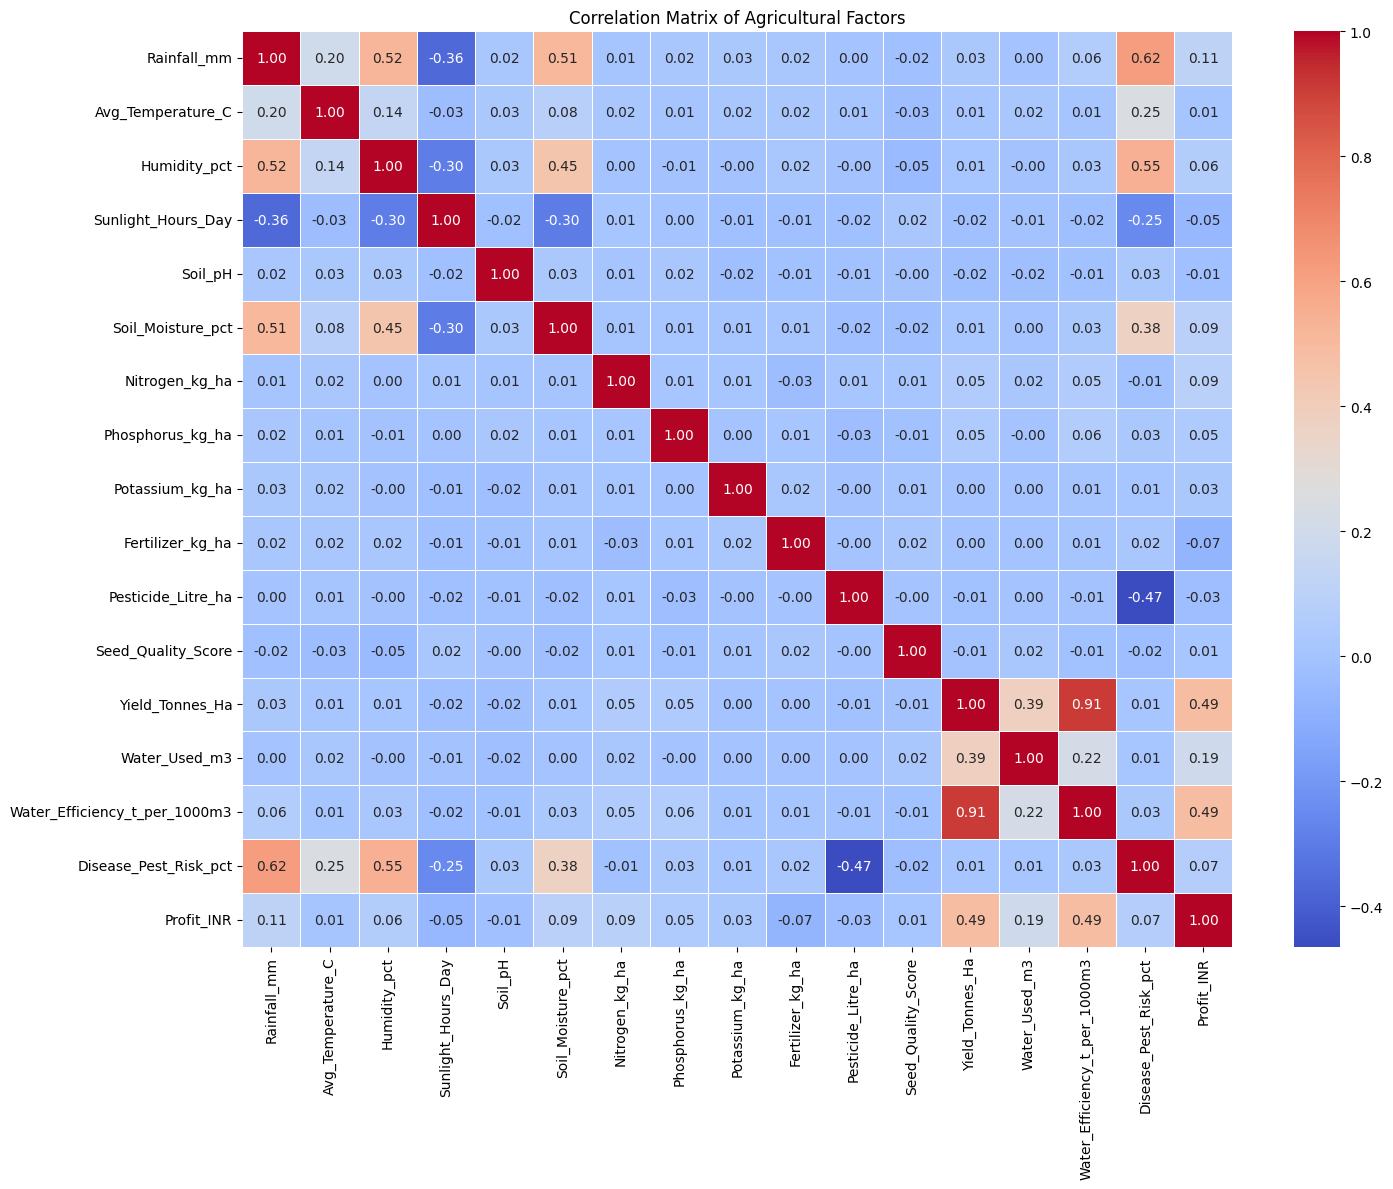

In [61]:
plt.figure(figsize=(15, 12))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Agricultural Factors')
plt.tight_layout()
plt.show()

Create a final summary table

In [59]:
summary = pd.DataFrame({
    "Metric": [
        "Total Farms",
        "Total Production",
        "Total Revenue",
        "Total Cost",
        "Total Profit",
        "Average Yield",
        "Average Water Efficiency",
        "Profitable Farms",
        "Loss-Making Farms"
    ],

    "Value": [
        total_farms,
        round(total_production, 2),
        round(total_revenue, 2),
        round(total_cost, 2),
        round(total_profit, 2),
        round(average_yield, 2),
        round(average_water_efficiency, 2),
        len(profitable_farms),
        len(loss_farms)
    ]
})

summary

,Metric,Value
0,Total Farms,4.000000e+03
1,Total Production,1.729848e+05
2,Total Revenue,2.551440e+09
3,Total Cost,2.105214e+09
4,Total Profit,4.462259e+08
5,Average Yield,5.240000e+00
6,Average Water Efficiency,5.390000e+00
7,Profitable Farms,2.034000e+03
8,Loss-Making Farms,1.966000e+03


Export cleaned dataset

In [60]:
clean_df.to_csv(
    "cleaned_agriculture_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
